In [13]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

import matplotlib.pyplot as plt

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
BASE_DIR = "/content/drive/MyDrive/NLP"

DATA_DIR = f"{BASE_DIR}/datasets"
MODEL_DIR = f"{BASE_DIR}/models"
RESULTS_DIR = f"{BASE_DIR}/results"

import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [16]:
def load_all_datasets():
    paths = {
        'imdb': os.path.join(DATA_DIR, 'imdb.csv'),
        'rotten': os.path.join(DATA_DIR, 'rotten.csv'),
        'amazon': os.path.join(DATA_DIR, 'amazon.csv'),
        'yelp': os.path.join(DATA_DIR, 'yelp.csv')
    }

    datasets = {}

    for name, path in paths.items():
        df = pd.read_csv(path)
        df = df[['text', 'label']].dropna()
        df['label'] = df['label'].astype(int)

        datasets[name] = df

    return datasets

In [17]:
def compute_max_len(datasets, percentile=0.95):
    stats = {}

    for name, df in datasets.items():
        lengths = df['text'].apply(lambda x: len(str(x).split()))

        max_len = int(np.percentile(lengths, percentile * 100))

        stats[name] = {
            'mean_len': np.mean(lengths),
            'max_len': np.max(lengths),
            'recommended_max_len': max_len
        }

        print(f"\n=== {name} ===")
        print(f"Mean: {stats[name]['mean_len']:.2f}")
        print(f"Max: {stats[name]['max_len']}")
        print(f"Recommended MAX_LEN (p{int(percentile*100)}): {max_len}")

    return stats

In [18]:
datasets = load_all_datasets()
max_lengths = compute_max_len(datasets)


=== imdb ===
Mean: 225.19
Max: 2441
Recommended MAX_LEN (p95): 575

=== rotten ===
Mean: 21.13
Max: 51
Recommended MAX_LEN (p95): 37

=== amazon ===
Mean: 82.43
Max: 1773
Recommended MAX_LEN (p95): 248

=== yelp ===
Mean: 129.38
Max: 937
Recommended MAX_LEN (p95): 344


In [19]:
MAX_WORDS = 20000
MAX_LEN = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 20
N_SPLITS = 5

In [20]:
def build_lstm(max_features, max_len,
                        embedding_dim=128,
                        lstm_units=128,
                        dropout_rate=0.5):

    model = Sequential()

    model.add(Embedding(
        input_dim=max_features,
        output_dim=embedding_dim,
        input_length=max_len
    ))

    model.add(LSTM(lstm_units))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [24]:
all_train_texts = []
for d in datasets:
    all_train_texts.extend(datasets[d]['text'].values)

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(all_train_texts)

In [25]:
def run_ood_experiment(datasets,
                       max_features,
                       max_lengths,
                       epochs,
                       batch_size,
                       n_splits=5,
                       lstm_units=128,
                       dropout_rate=0.5,
                       save_dir='models'):

    results = []
    training_logs = []

    domains = list(datasets.keys())

    for train_domain in domains:

        print("\n" + "="*80)
        print(f"TRAIN DOMAIN: {train_domain}")
        print("="*80)

        df = datasets[train_domain].reset_index(drop=True)
        max_len = max_lengths[train_domain]['recommended_max_len']
        print(f"Using MAX_LEN for {train_domain}: {max_len}")

        X_text = df['text'].values
        y = df['label'].values

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        fold_id = 0

        for train_idx, val_idx in kf.split(X_text):

            fold_id += 1
            print(f"\nFold {fold_id}/{n_splits}")

            X_train_text = X_text[train_idx]
            X_val_text = X_text[val_idx]

            y_train = y[train_idx]
            y_val = y[val_idx]

            X_train = pad_sequences(
                tokenizer.texts_to_sequences(X_train_text),
                maxlen=max_len
            )

            X_val = pad_sequences(
                tokenizer.texts_to_sequences(X_val_text),
                maxlen=max_len
            )

            model = build_lstm(
                max_features=max_features,
                max_len=max_len,
                embedding_dim=100,
                lstm_units=lstm_units,
                dropout_rate=dropout_rate
            )
            model_name = f"{train_domain}_fold{fold_id}.keras"
            model_path = os.path.join(
                MODEL_DIR,
                f"{train_domain}_fold{fold_id}.keras"
            )

            early_stop = EarlyStopping(
                    monitor='val_loss',
                    patience=3,
                    restore_best_weights=True,
                    verbose=1
            )

            checkpoint = ModelCheckpoint(
                filepath=model_path,
                monitor='val_loss',
                save_best_only=True,
                save_weights_only=False,
                verbose=1
            )

            print("Training...")
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop, checkpoint],
                verbose=1
            )

            # log training
            for e in range(len(history.history['loss'])):
                training_logs.append({
                    'train_domain': train_domain,
                    'fold': fold_id,
                    'epoch': e,
                    'loss': history.history['loss'][e],
                    'acc': history.history['accuracy'][e],
                    'val_loss': history.history['val_loss'][e],
                    'val_acc': history.history['val_accuracy'][e]
                })

            print("IN-DOMAIN EVAL")
            preds = (model.predict(X_val, verbose=0) > 0.5).astype(int)
            acc = accuracy_score(y_val, preds)
            prec = precision_score(y_val, preds, zero_division=0)
            rec = recall_score(y_val, preds, zero_division=0)
            f1 = f1_score(y_val, preds, zero_division=0)

            results.append({
                'train_domain': train_domain,
                'test_domain': train_domain,
                'fold': fold_id,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'eval_type': "IND"
            })

            print(f"{train_domain} for {train_domain} | F1: {f1:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

            print("OUT-OF-DOMAIN EVAL")
            for test_domain, test_df in datasets.items():
                if test_domain == train_domain:
                    continue

                X_test_text = test_df['text'].values
                y_test = test_df['label'].values

                X_test = pad_sequences(
                    tokenizer.texts_to_sequences(X_test_text),
                    maxlen=max_len
                )

                preds = (model.predict(X_test, verbose=0) > 0.5).astype(int)

                acc = accuracy_score(y_test, preds)
                prec = precision_score(y_test, preds, zero_division=0)
                rec = recall_score(y_test, preds, zero_division=0)
                f1 = f1_score(y_test, preds, zero_division=0)

                results.append({
                    'train_domain': train_domain,
                    'test_domain': test_domain,
                    'fold': fold_id,
                    'accuracy': acc,
                    'precision': prec,
                    'recall': rec,
                    'f1': f1,
                    'eval_type': "OOD"
                })

                print(f"{train_domain} for {test_domain} | F1: {f1:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

    return pd.DataFrame(training_logs), pd.DataFrame(results)

In [26]:
training_logs, ood_results = run_ood_experiment(
    datasets=datasets,
    max_features=MAX_WORDS,
    max_lengths=max_lengths,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    n_splits=5,
    lstm_units=128,
    dropout_rate=0.5
)


TRAIN DOMAIN: imdb
Using MAX_LEN for imdb: 575

Fold 1/5
Training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6981 - loss: 0.5553
Epoch 1: val_loss improved from None to 0.31577, saving model to /content/drive/MyDrive/NLP/models/imdb_fold1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/imdb_fold1.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7873 - loss: 0.4523 - val_accuracy: 0.8605 - val_loss: 0.3158
Epoch 2/20
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8976 - loss: 0.2684
Epoch 2: val_loss improved from 0.31577 to 0.28751, saving model to /content/drive/MyDrive/NLP/models/imdb_fold1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP/models/imdb_fold1.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9002 - loss: 0.2631 - val_accuracy: 0.8873 - val_loss: 0.2875
Epoch 3/20
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9152 - loss: 0.2243
Epoch 3: val_loss did not improve from 0.28751
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7569 - loss: 0.4865
Epoch 1: val_loss improved from None to 0.29272, saving model to /content/drive/MyDrive/NLP/models/imdb_fold2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/imdb_fold2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8177 - loss: 0.4096 - val_accuracy: 0.8832 - val_loss: 0.2927
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9044 - loss: 0.2529
Epoch 2: val_loss did not improve from 0.29272
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9044 - loss: 0.2530 - val_accuracy: 0.8851 - val_loss: 0.2957
Epoch 3/20
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9396 - loss: 0.1687
Epoch 3: val_loss did not improve from 0.29272
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9332 - loss: 0.1820 - val_accuracy: 0.8598 - val_loss: 0.3353
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9557 - loss: 0.1295
Epoch 4: v

...

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8176 - loss: 0.4880
Epoch 1: val_loss improved from None to 0.38044, saving model to /content/drive/MyDrive/NLP/models/yelp_fold3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold3.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8346 - loss: 0.4244 - val_accuracy: 0.7990 - val_loss: 0.3804
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8853 - loss: 0.3103
Epoch 2: val_loss improved from 0.38044 to 0.31458, saving model to /content/drive/MyDrive/NLP/models/yelp_fold3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold3.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8925 - loss: 0.2791 - val_accuracy: 0.8770 - val_loss: 0.3146
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9401 - loss: 0.1620
Epoch 3: val_loss improved from 0.31458 to 0.31375, saving model to /content/drive/MyDrive/NLP/models/yelp_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8203 - loss: 0.4929
Epoch 1: val_loss improved from None to 0.36306, saving model to /content/drive/MyDrive/NLP/models/yelp_fold4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold4.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8375 - loss: 0.4294 - val_accuracy: 0.8455 - val_loss: 0.3631
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8914 - loss: 0.2672
Epoch 2: val_loss improved from 0.36306 to 0.27701, saving model to /content/drive/MyDrive/NLP/models/yelp_fold4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold4.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8969 - loss: 0.2577 - val_accuracy: 0.8810 - val_loss: 0.2770
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9480 - loss: 0.1434
Epoch 3: val_loss did not improve from 0.27701
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9431

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8111 - loss: 0.4888
Epoch 1: val_loss improved from None to 0.35420, saving model to /content/drive/MyDrive/NLP/models/yelp_fold5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold5.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8350 - loss: 0.4184 - val_accuracy: 0.8565 - val_loss: 0.3542
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8968 - loss: 0.2591
Epoch 2: val_loss improved from 0.35420 to 0.26922, saving model to /content/drive/MyDrive/NLP/models/yelp_fold5.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NLP/models/yelp_fold5.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9057 - loss: 0.2430 - val_accuracy: 0.8945 - val_loss: 0.2692
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9466 - loss: 0.1548
Epoch 3: val_loss did not improve from 0.26922
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9416

In [27]:
training_logs, ood_results

(   train_domain  fold  epoch      loss       acc  val_loss  val_acc
 0          imdb     1      0  0.452270  0.787350  0.315771   0.8605
 1          imdb     1      1  0.263089  0.900225  0.287512   0.8873
 2          imdb     1      2  0.219443  0.917425  0.327268   0.8889
 3          imdb     1      3  0.166280  0.939975  0.338365   0.8806
 4          imdb     1      4  0.123954  0.956875  0.316928   0.8915
 ..          ...   ...    ...       ...       ...       ...      ...
 95         yelp     5      0  0.418447  0.835000  0.354200   0.8565
 96         yelp     5      1  0.243022  0.905750  0.269215   0.8945
 97         yelp     5      2  0.163678  0.941625  0.285436   0.8885
 98         yelp     5      3  0.114666  0.958250  0.363844   0.8720
 99         yelp     5      4  0.078950  0.971875  0.383240   0.8760
 
 [100 rows x 7 columns],
    train_domain test_domain  fold  accuracy  precision    recall        f1  \
 0          imdb        imdb     1  0.887300   0.859031  0.928756 

In [28]:
import os

SAVE_DIR = "/content/drive/MyDrive/NLP/results"
os.makedirs(SAVE_DIR, exist_ok=True)

training_logs.to_csv(
    os.path.join(SAVE_DIR, "training_logs.csv"),
    index=False
)
ood_results.to_csv(
    os.path.join(SAVE_DIR, "ood_results.csv"),
    index=False
)

print("Saved:")
print(" - training_logs.csv")
print(" - ood_results.csv")

Saved:
 - training_logs.csv
 - ood_results.csv


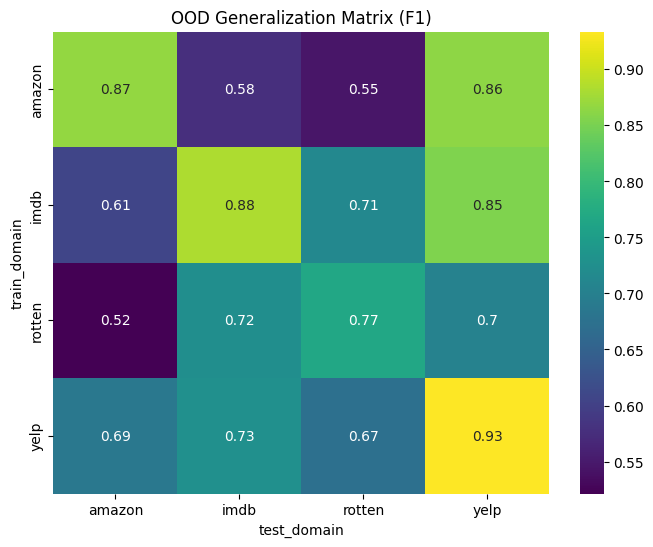

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = ood_results
pivot = df.groupby(["train_domain", "test_domain"])["f1"].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("OOD Generalization Matrix (F1)")
plt.show()

<Figure size 1000x500 with 0 Axes>

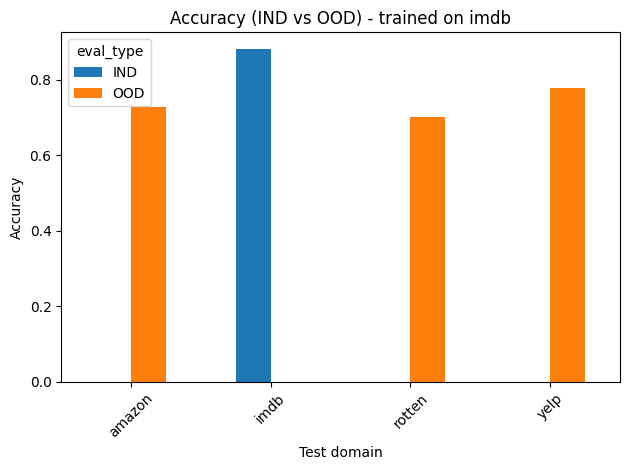

<Figure size 1000x500 with 0 Axes>

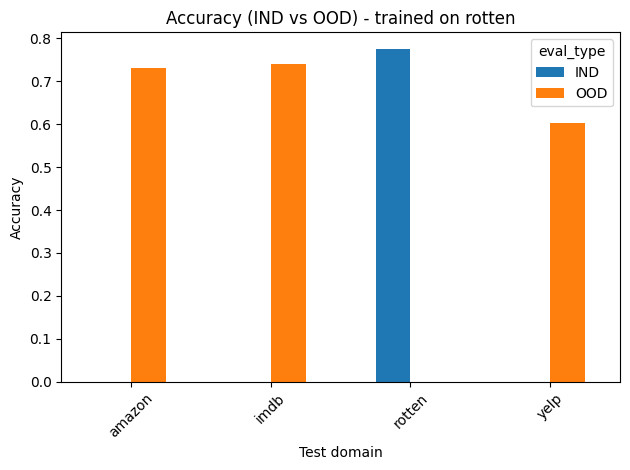

<Figure size 1000x500 with 0 Axes>

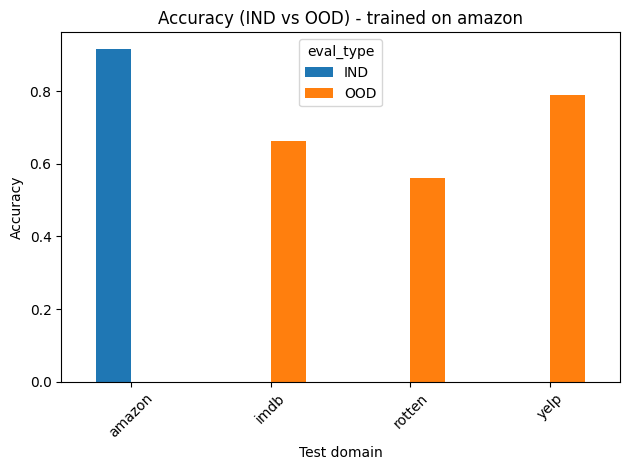

<Figure size 1000x500 with 0 Axes>

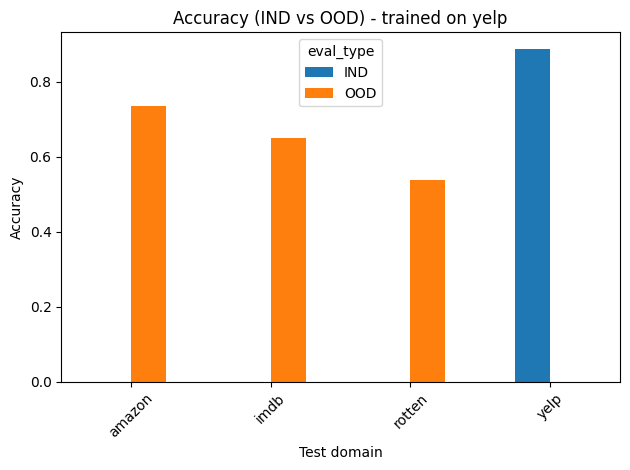

In [33]:
import matplotlib.pyplot as plt

df = ood_results

train_domains = df['train_domain'].unique()

for train_domain in train_domains:
    subset = df[df['train_domain'] == train_domain]

    pivot = subset.pivot_table(
        index='test_domain',
        columns='eval_type',
        values='accuracy',
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 5))
    pivot.plot(kind='bar')

    plt.title(f"Accuracy (IND vs OOD) - trained on {train_domain}")
    plt.xlabel("Test domain")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)

    plt.tight_layout()

plt.show()